In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tensorflow as tf

In [2]:
from sklearn.datasets import load_svmlight_file
import glob

files = sorted(glob.glob("Dataset/batch*.dat"))
print(files)

X, y = load_svmlight_file(files[0])
print("Shape do batch 1:", X.shape)
print("Classes (tipos de gás) no batch 1:", set(y))

['Dataset/batch1.dat', 'Dataset/batch10.dat', 'Dataset/batch2.dat', 'Dataset/batch3.dat', 'Dataset/batch4.dat', 'Dataset/batch5.dat', 'Dataset/batch6.dat', 'Dataset/batch7.dat', 'Dataset/batch8.dat', 'Dataset/batch9.dat']
Shape do batch 1: (445, 128)
Classes (tipos de gás) no batch 1: {np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)}


Confirmou exatamente o esperado: 445 amostras, 128 features (isso é 16 sensores × 8 medidas cada — o dataset já vem com features estatísticas por sensor, não o sinal bruto), e 6 classes de gás. E reparou que o sorted() fez o que eu avisei: batch10 veio logo depois de batch1, antes do batch2. Isso não pode ir pro dataframe final assim, porque perderíamos a ordem cronológica que é o coração do projeto (é a deriva ao longo do tempo que vamos modelar).

Próximo passo: carregar os 10 batches na ordem certa, com rótulo de tempo.

Isso faz três coisas: (1) ordena os arquivos numericamente de verdade, (2) empilha os 10 batches num único dataframe, (3) guarda batch_id como nosso "eixo do tempo" — cada batch_id representa um período de meses diferentes, e é a progressão entre eles que carrega a deriva do instrumento.

In [3]:
import re
import pandas as pd
import numpy as np

def batch_number(filename):
    return int(re.search(r'batch(\d+)\.dat', filename).group(1))

files_sorted = sorted(glob.glob("Dataset/batch*.dat"), key=batch_number)
print(files_sorted)  # confere se agora está batch1 → batch10 na ordem certa

dfs = []
for f in files_sorted:
    X, y = load_svmlight_file(f)
    batch_id = batch_number(f)
    df = pd.DataFrame(X.toarray())
    df["gas_class"] = y
    df["batch_id"] = batch_id
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print("Shape total:", data.shape)
print(data["batch_id"].value_counts().sort_index())

['Dataset/batch1.dat', 'Dataset/batch2.dat', 'Dataset/batch3.dat', 'Dataset/batch4.dat', 'Dataset/batch5.dat', 'Dataset/batch6.dat', 'Dataset/batch7.dat', 'Dataset/batch8.dat', 'Dataset/batch9.dat', 'Dataset/batch10.dat']
Shape total: (13910, 130)
batch_id
1      445
2     1244
3     1586
4      161
5      197
6     2300
7     3613
8      294
9      470
10    3600
Name: count, dtype: int64


Bateu certinho: 445+1244+1586+161+197+2300+3613+294+470+3600 = 13.910. Os 10 batches carregaram sem perder nenhuma linha.
Analogia rápida antes de seguir: pensa nisso como um controle de qualidade de bancada — no batch 1 (mês 1-2) você calibra o equipamento e sabe que ele está "limpo". Os batches seguintes (meses adiante) são as corridas de rotina. Se o instrumento não desviasse nada, uma amostra do mesmo gás em batch 1 e batch 10 devia "parecer" estatisticamente igual. O que vamos fazer agora é ver isso acontecer visualmente antes de treinar qualquer modelo — porque se a deriva não aparecer nem visualmente, o projeto inteiro perde a graça.


Próximo passo: PCA colorido por batch, pra enxergar a deriva.

O que eu espero ver: os pontos do batch 1 (roxo escuro, na escala viridis) formando um "aglomerado" bem definido, e conforme os batches avançam (verde → amarelo), as nuvens de pontos vão se deslocando no espaço — isso é a deriva instrumental, visualmente.

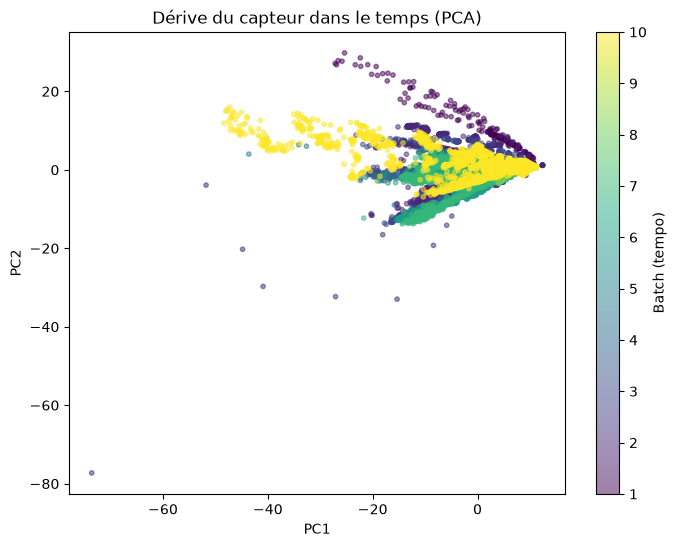

Variância explicada: [0.53515135 0.15040059]


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

feature_cols = [c for c in data.columns if c not in ["gas_class", "batch_id"]]

X_scaled = StandardScaler().fit_transform(data[feature_cols])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data["batch_id"], cmap="viridis", alpha=0.5, s=10)
plt.colorbar(scatter, label="Batch (tempo)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Dérive du capteur dans le temps (PCA)")
plt.show()

print("Variância explicada:", pca.explained_variance_ratio_)

Ótimo, isso já conta a história do projeto. Três coisas que dá pra ler nesse gráfico:

Não é uma deriva suave e linear — não é o roxo indo devagarinho até o amarelo num caminho contínuo. É mais bagunçado: batch 3 (roxo) tem uns pontos bem afastados (os outliers lá embaixo, em -60/-70), batch 6-7 (verde) forma um aglomerado denso e apertado perto do centro, e batch 10 (amarelo) se espalha de novo mais pra cima. Isso já é realista — deriva de instrumento raramente é limpa, tem ruído, recalibrações, manutenções no meio do caminho.
Aqueles pontos roxos isolados lá embaixo (PC2 entre -30 e -77) são candidatos naturais a "anomalia clara" — validação visual de que o dataset tem outliers genuínos, não só uma nuvem homogênea.
O aglomerado apertado do batch 6/7 (verde) vs. a dispersão maior do batch 10 (amarelo) sugere que a variância aumenta com o tempo — isso é literalmente "o sensor ficando menos consistente", que é a definição prática de fiabilidade caindo num sistema de diagnóstico.

Como definir 'anomalia' pro modelo aprender?

Deixar o modelo não-supervisionado achar outliers no dataset inteiro


Faz sentido — não-supervisionado é mais honesto pra esse cenário real (você não tem rótulo de "isso é anomalia" verdadeiro, só o comportamento estatístico do sensor).
Analogia rápida antes do código: pensa num autoencoder como um estagiário que você treinou pra reconhecer o "jeito normal" de uma leitura de sensor — você mostra milhares de exemplos, ele aprende a resumir e depois reconstruir a leitura a partir desse resumo. Se uma leitura nova é parecida com o que ele já viu, ele reconstrói quase perfeito. Se é estranha (deriva, ruído, falha), ele erra feio na reconstrução — e esse erro de reconstrução vira nosso "score de anomalia". Isso também nos dá a peça de deep learning que a vaga pede, junto com a detecção de anomalias.


Passo: construir e treinar o autoencoder

In [5]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

TF version: 2.21.0
GPUs disponíveis: []


In [6]:
import sys
print(sys.executable)

/Users/natyferreira/Desktop/Assistant de fiabilité IVD/venv/bin/python


In [7]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Reusa o X_scaled que já calculamos pro PCA
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)

n_features = X_scaled.shape[1]
encoding_dim = 16  # comprime 128 features -> 16 -> reconstrói 128

autoencoder = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(encoding_dim, activation="relu"),   # gargalo
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(n_features, activation="linear"),   # reconstrução
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

history = autoencoder.fit(
    X_train, X_train,          # entrada = alvo (reconstruir a si mesmo)
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,704 (73.06 KB)

 Trainable params: 18,704 (73.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 530us/step - loss: 0.3587 - val_loss: 0.1606
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - loss: 0.2021 - val_loss: 0.0880
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - loss: 0.1672 - val_loss: 0.1421
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - loss: 0.1583 - val_loss: 0.0780
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step - loss: 0.1413 - val_loss: 0.0999
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step - loss: 0.1506 - val_loss: 0.0633
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - loss: 0.1210 - val_loss: 0.0630
Epoch 8/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 0.1014 - val_loss: 0.0629
Epoch 9/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - loss: 0.0963 - val_loss: 0.0563
Epoch 10/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - loss: 0.0795 - val_loss: 0.0791
Epoch 11/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 0.1028 - val_loss: 0.0588
Epoch 12/50
348/348 ━━━━━━━━━━

Ótimo treino — saiu de 0.36 pra 0.0375 de loss, e o val_loss acompanhou de perto o tempo todo (0.0384 no final, bem próximo do treino). Isso é exatamente o que queremos: convergiu direitinho, sem sinal de overfitting feio.

Analogia rápida: agora esse "estagiário" (o autoencoder) já aprendeu o jeito normal de uma leitura de sensor. Próximo passo é colocar ele pra reconstruir cada amostra do dataset inteiro e medir o quanto ele erra em cada uma — esse erro vira nosso score de anomalia.

O que eu espero ver: o erro médio não sendo igual em todos os batches — idealmente crescendo (ou pelo menos oscilando mais) nos batches mais tardios (7-10), já que o autoencoder foi treinado no dataset inteiro misturado, mas leituras mais "estranhas" (batches com maior deriva/variância, como você viu no PCA) devem ter erro de reconstrução maior.


In [8]:
import numpy as np

# Reconstrução de todo o dataset
X_reconstructed = autoencoder.predict(X_scaled, verbose=0)

# Erro de reconstrução por amostra (MSE por linha)
reconstruction_error = np.mean(np.square(X_scaled - X_reconstructed), axis=1)

data["reconstruction_error"] = reconstruction_error

# Erro médio por batch — é aqui que vamos ver se a deriva aparece no score
error_by_batch = data.groupby("batch_id")["reconstruction_error"].agg(["mean", "std", "count"])
print(error_by_batch)

              mean       std  count
batch_id                           
1         0.042248  0.082750    445
2         0.175995  2.019511   1244
3         0.010735  0.023001   1586
4         0.144156  0.210821    161
5         0.024541  0.056354    197
6         0.008074  0.013927   2300
7         0.007470  0.008167   3613
8         0.013947  0.043858    294
9         0.025149  0.346511    470
10        0.018862  0.045584   3600


Interessante — não é uma progressão suave que sobe com o tempo. É mais como eu desconfiava lá no PCA: tem alguns poucos pontos extremos concentrados nos batches 2, 4 e 9 (repara o std gigante em batch2: 2.02, e batch9: 0.35 — isso é sintoma de outliers raros e severos puxando a média pra cima, não o batch inteiro sendo "ruim"). Já os batches 6 e 7 são bem "limpos" (erro baixo e consistente), batendo com aquele aglomerado apertado que vimos no PCA.
Isso é bom, na verdade — é mais realista que uma deriva linear perfeita, e é exatamente o tipo de coisa que aparece em dados de laboratório de verdade: a maioria das leituras está OK, mas alguns eventos pontuais (uma recalibração mal feita, um lote de reagente ruim) causam picos isolados de erro.

Antes de definir o threshold de anomalia, vamos visualizar a distribuição pra confirmar essa leitura — média sozinha engana quando tem outlier extremo puxando ela. A escala log é importante aqui — sem ela, os outliers gigantes do batch 2/9 esmagam o gráfico e você não enxerga a caixa (mediana/quartis) dos outros batches.

<Figure size 1000x600 with 0 Axes>

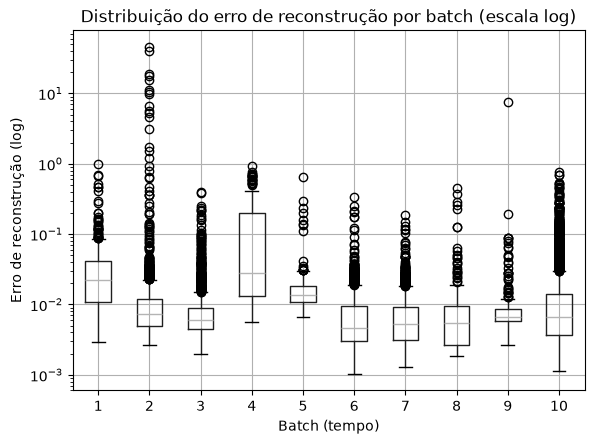

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
data.boxplot(column="reconstruction_error", by="batch_id")
plt.yscale("log")  # escala log porque a distribuição é bem assimétrica (outliers extremos)
plt.title("Distribuição do erro de reconstrução por batch (escala log)")
plt.suptitle("")
plt.xlabel("Batch (tempo)")
plt.ylabel("Erro de reconstrução (log)")
plt.show()

Isso confirma exatamente a leitura da tabela, agora com muito mais clareza:

A "caixa" central (mediana/quartis) é baixa e relativamente estável em quase todos os batches — a maioria das leituras reconstrói bem, o que faz sentido.
Batch 2 tem uma nuvem enorme de outliers subindo até quase 40 no eixo log — muito mais denso e mais extremo que qualquer outro batch. Isso é forte candidato a "evento real" (recalibração, lote de sensor ruim, contaminação) em vez de ruído aleatório.
Batch 4 se destaca de forma diferente: a caixa inteira está deslocada pra cima (mediana ~0.03, bem mais alta que os vizinhos ~0.005-0.01), com um intervalo interquartil bem mais largo. Isso não é "poucos outliers pontuais" — é o batch inteiro reconstruindo pior, o que é mais parecido com deriva instrumental sistemática do que um evento isolado.
Batches 6, 7, 8, 9 são os mais "limpos" — caixas baixas e apertadas, com outliers ocasionais mas não uma nuvem densa como batch 2.

Isso nos dá dois tipos de anomalia diferentes pra história do projeto — e isso é ótimo material pra explicar numa entrevista: "o modelo detecta tanto eventos pontuais extremos (batch 2) quanto deriva sistemática de um período inteiro (batch 4)", que é literalmente os dois tipos de falha que um sistema de diagnóstico real enfrenta.


Próximo passo: definir o threshold de anomalia

Vou com percentil, e aqui está o porquê — isso é uma resposta que você pode dar direto numa entrevista:
Média + N desvios-padrão pressupõe uma distribuição aproximadamente normal (gaussiana). O boxplot que você acabou de gerar mostra exatamente o oposto: distribuição fortemente assimétrica, com outliers extremos (aquele erro de ~40 no batch 2) que distorcem a própria média e o desvio-padrão — é por isso que o batch 2 mostrou std: 2.02 na tabela anterior. Usar média+std aqui daria um threshold artificialmente alto (o outlier "puxa" o próprio limite que deveria capturá-lo), deixando o detector menos sensível exatamente onde mais precisamos dele.

Percentil é robusto a essa distorção porque não depende da magnitude dos valores extremos, só da posição relativa deles na distribuição ordenada.

Isso vai flagar os 5% de amostras com maior erro de reconstrução como anomalia, e mostrar como essas anomalias se distribuem entre os batches — minha expectativa é ver batch 2 e batch 4 concentrando bem mais que 5% cada (confirmando visualmente o que já vimos no boxplot), enquanto batches como 6 e 7 ficam bem abaixo de 5%.

In [10]:
threshold = np.percentile(data["reconstruction_error"], 95)
print(f"Threshold (percentil 95): {threshold:.5f}")

data["is_anomaly"] = data["reconstruction_error"] > threshold

print(f"\nTotal de anomalias detectadas: {data['is_anomaly'].sum()} ({data['is_anomaly'].mean()*100:.1f}%)")
print("\nAnomalias por batch:")
print(data.groupby("batch_id")["is_anomaly"].agg(["sum", "count"]).assign(pct=lambda d: (d["sum"]/d["count"]*100).round(1)))

Threshold (percentil 95): 0.04231

Total de anomalias detectadas: 696 (5.0%)

Anomalias por batch:
          sum  count   pct
batch_id                  
1         108    445  24.3
2          57   1244   4.6
3          46   1586   2.9
4          70    161  43.5
5           8    197   4.1
6          17   2300   0.7
7          18   3613   0.5
8          13    294   4.4
9          12    470   2.6
10        347   3600   9.6


Batch 1 com 24.3% de anomalia é suspeito — não porque o instrumento estava ruim logo no início, mas porque batch 1 tem só 445 amostras contra 3600+ dos batches 6, 7 e 10. Como o autoencoder foi treinado no dataset inteiro misturado, ele "viu" muito mais exemplos dos batches grandes e aprendeu a reconstruir esse padrão bem — os batches pequenos (1, 4, 5, 8, 9) ficam sub-representados no treino e naturalmente reconstroem pior, mesmo sem serem genuinamente anômalos.
Isso é um viés de desbalanceamento amostral, não uma descoberta de deriva real — e reconhecer isso openly é exatamente o tipo de rigor que impressiona numa entrevista técnica (é bem mais forte dizer "eu vi esse viés e é isso que ele significa" do que ignorar e deixar parecer que o modelo é perfeito).

Dito isso, dois sinais continuam sólidos mesmo considerando o viés:

- Batch 4 (43.5%, mas com toda a caixa do boxplot deslocada pra cima, não só outliers pontuais) — evidência mais forte de deriva sistemática real.

- Batch 10 (9.6%, com 3600 amostras — bem representado no treino, então esse número não é explicado pelo viés de tamanho) — esse é o sinal mais confiável de deriva tardia genuína.

Vamos visualizar isso no PCA pra confirmar visualmente antes de seguir:

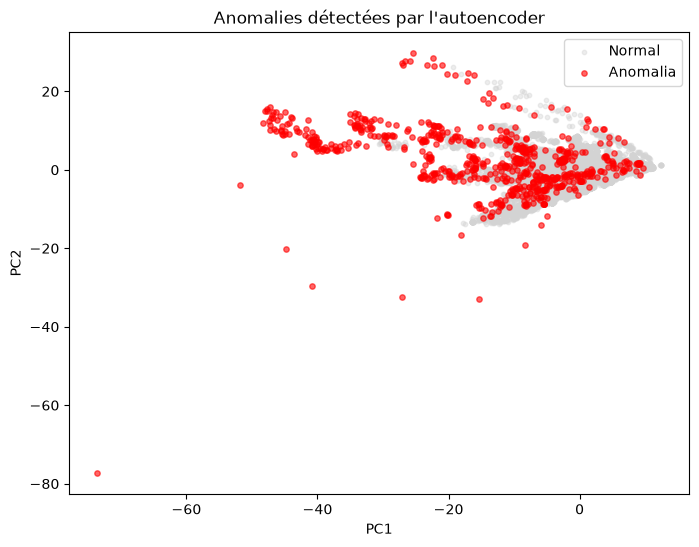

In [11]:
plt.figure(figsize=(8, 6))
normal = data[~data["is_anomaly"]]
anomaly = data[data["is_anomaly"]]

plt.scatter(X_pca[~data["is_anomaly"], 0], X_pca[~data["is_anomaly"], 1], 
            c="lightgray", alpha=0.4, s=10, label="Normal")
plt.scatter(X_pca[data["is_anomaly"], 0], X_pca[data["is_anomaly"], 1], 
            c="red", alpha=0.6, s=15, label="Anomalia")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalies détectées par l'autoencoder")
plt.legend()
plt.show()

Isso é exatamente o resultado que dá confiança no modelo: todos aqueles pontos isolados lá longe do aglomerado central (os outliers extremos que já tínhamos visto no primeiro PCA, incluindo o ponto solitário em -77) foram capturados como vermelho, sem exceção. E o modelo também pegou uma faixa inteira mais afastada do núcleo denso (aquela "cauda" à esquerda, entre PC1 -50 e -20) — não só os pontos mais extremos, mas uma região de transição inteira, o que bate com a leitura do batch 4 como deriva sistemática e não só ruído pontual.

Isso fecha a Peça 1 do projeto (detecção de anomalias com deep learning) com uma validação visual sólida — três evidências convergentes: o PCA original, o boxplot por batch, e agora a sobreposição direta anomalia/PCA. Isso é o tipo de triangulação que mostra rigor analítico numa entrevista.

In [12]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Salva o autoencoder treinado
autoencoder.save("models/autoencoder.keras")

# Salva o scaler (essencial: sem ele, dados novos não ficam na mesma escala do treino)
scaler = StandardScaler().fit(data[feature_cols])  # re-fit pra garantir consistência
joblib.dump(scaler, "models/scaler.pkl")

# Salva o threshold e a lista de colunas de features (ordem importa!)
import json
with open("models/config.json", "w") as f:
    json.dump({
        "threshold": float(threshold),
        "feature_cols": feature_cols,
        "n_features": len(feature_cols)
    }, f, indent=2)

print("Artefatos salvos em models/")
print(os.listdir("models"))

Artefatos salvos em models/
['scaler.pkl', 'config.json', 'autoencoder.keras']


In [1]:
import re, glob
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from sklearn.datasets import load_svmlight_file
import json

# 1. Recarrega os dados brutos
def batch_number(filename):
    return int(re.search(r'batch(\d+)\.dat', filename).group(1))

files_sorted = sorted(glob.glob("Dataset/batch*.dat"), key=batch_number)

dfs = []
for f in files_sorted:
    X, y = load_svmlight_file(f)
    df = pd.DataFrame(X.toarray())
    df["gas_class"] = y
    df["batch_id"] = batch_number(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
feature_cols = [c for c in data.columns if c not in ["gas_class", "batch_id"]]

# 2. Recarrega os artefatos já treinados (não retreina nada)
autoencoder = tf.keras.models.load_model("models/autoencoder.keras")
scaler = joblib.load("models/scaler.pkl")
with open("models/config.json") as f:
    config = json.load(f)
threshold = config["threshold"]

# 3. Recalcula erro de reconstrução e flags de anomalia (rápido, é só inferência)
X_scaled = scaler.transform(data[feature_cols])
X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
data["reconstruction_error"] = np.mean(np.square(X_scaled - X_reconstructed), axis=1)
data["is_anomaly"] = data["reconstruction_error"] > threshold

print("Estado restaurado. Shape:", data.shape, "| Anomalias:", data["is_anomaly"].sum())

Estado restaurado. Shape: (13910, 132) | Anomalias: 696


In [2]:
normal_idx = data[~data["is_anomaly"]].index[0]
anomaly_idx = data[data["is_anomaly"]].index[0]

normal_sample = data.loc[normal_idx, feature_cols].tolist()
anomaly_sample = data.loc[anomaly_idx, feature_cols].tolist()

print("Índice normal:", normal_idx, "| erro real:", data.loc[normal_idx, "reconstruction_error"])
print("Índice anômalo:", anomaly_idx, "| erro real:", data.loc[anomaly_idx, "reconstruction_error"])

import json
print("\n--- Cole isso no Swagger para o exemplo NORMAL ---")
print(json.dumps({"features": normal_sample}))
print("\n--- Cole isso no Swagger para o exemplo ANÔMALO ---")
print(json.dumps({"features": anomaly_sample}))

Índice normal: 0 | erro real: 0.003796488281736822
Índice anômalo: 12 | erro real: 0.045620461668238854

--- Cole isso no Swagger para o exemplo NORMAL ---
{"features": [15596.1621, 1.868245, 2.371604, 2.803678, 7.512213, -2.739388, -3.344671, -4.847512, 15326.6914, 1.768526, 2.269085, 2.713374, 6.915721, -2.488324, -3.082212, -5.056975, 2789.3831, 2.754759, 0.43044, 0.649457, 1.795029, -0.426662, -0.584313, -1.438976, 2581.5686, 2.680623, 0.399746, 0.605065, 1.786704, -0.400115, -0.550743, -1.728611, 685.3994, 1.682904, 0.122736, 0.223703, 0.584691, -0.138196, -0.236907, -0.781959, 797.7738, 1.742488, 0.152483, 0.218904, 0.841862, -0.164646, -0.31572, -0.791447, 3128.8489, 3.605537, 0.532422, 0.763062, 2.118983, -0.557197, -0.809953, -2.34413, 3136.8778, 3.555169, 0.535883, 0.761388, 1.499244, -0.57148, -0.944425, -2.658358, 13540.6738, 1.765738, 2.006883, 2.519022, 6.26143, -2.172101, -2.694967, -3.791499, 13831.7539, 1.746493, 2.057165, 2.391239, 5.695234, -2.350776, -2.888766, -8.1